# Algorithmic Efficiency in Practice

## List Rearrangements

### Problem Statement

Write a function that returns `True` if two lists contain the same elements with the same number of occurrences, possibly in different orders. Otherwise return `False`.

In other words, return `True` if one list is a permutation of the other.

#### Examples

```
[1, 2, 2, 5] and [2, 5, 2, 1] → True
[1, 2, 2] and [1, 2, 3] → False
[1, 2] and [1, 2, 2] → False
```

### Brute Force Implementation

As a first approach, we will implement a **brute force** solution.

**Approach:**
Cross-off strategy. Make a copy of list `B`. Visit every element in list `A`. For each element, remove one matching occurrence from the copy of `B`.
If at any point the element is not found, return `False`.
If the copy of `B` is empty at the end, then the lists are permutations of each other.

**Time Complexity:** `O(n²)`
(For each of the `n` elements in `A`, we may search through up to `n` elements in `B`.)

**Extra Space Required:** `O(n)` due to the copy of list `B`.

In [2]:
def are_rearrangements_brute(a, b):
  if len(a) != len(b):
    return False
  b_copy = b.copy()
  for element in a:
    if element in b_copy:
      b_copy.remove(element)
    else:
      return False
  return len(b_copy) == 0

In [3]:

assert are_rearrangements_brute([], []) is True
assert are_rearrangements_brute([1], [1]) is True
assert are_rearrangements_brute([1,2,2], [2,1,2]) is True
assert are_rearrangements_brute([1,2,2], [1,2,3]) is False
assert are_rearrangements_brute([1,2], [1,2,2]) is False
assert are_rearrangements_brute(["a","b","a"], ["b","a","a"]) is True
assert are_rearrangements_brute(["ab", "c"], ["a", "bc"]) is False
print("All tests passed.")

All tests passed.


## Sorting Implementation

As a second approach, we will improve the efficiency by using sorting.

**Approach:**
Sort both list `A` and list `B`.
Once sorted, compare the two lists element by element.
If they are identical after sorting, then the lists are permutations of each other.
If they differ at any position, return `False`.

**Time Complexity:** `O(n log n)`
(Sorting each list of size `n` takes `O(n log n)` time. The final comparison takes `O(n)`, which does not change the overall complexity.)

**Extra Space Required:** `O(n)`
(We should not sort the lists in place because we might be part of a system that needs the lists unchamged. Thus, we need to create sorted copies of both lists.)

In [4]:
def are_rearrangements_sort(a, b):
  return sorted(a) == sorted(b)

In [5]:

assert are_rearrangements_sort([], []) is True
assert are_rearrangements_sort([1], [1]) is True
assert are_rearrangements_sort([1,2,2], [2,1,2]) is True
assert are_rearrangements_sort([1,2,2], [1,2,3]) is False
assert are_rearrangements_sort([1,2], [1,2,2]) is False
assert are_rearrangements_sort(["a","b","a"], ["b","a","a"]) is True
assert are_rearrangements_sort(["ab", "c"], ["a", "bc"]) is False
print("All tests passed.")

All tests passed.


### Dictionary Implementation

As a third approach, we will use a dictionary to achieve linear time complexity.

**Approach:**
Make a dictionary of each element from `A` with its count.
Make a dictionary of each element from `B` with its count.
Check if the two dictionaries are the same.

**Time Complexity:** `O(n)` (expected)
We perform a linear pass over list `A` to create a dictionary, then a linear pass over list `B` to create a dictionary.  Comparing the two dictionaries requires at most `n` comparisons.

**Extra Space Required:** `O(n)`
The two dictionaries require additional memory proportional to `n`.

In [6]:
def are_rearrangements_dict(a, b):
  if len(a) != len(b):
    return False
  ad = {}
  bd = {}
  for element in a:
    ad[element] = ad.get(element, 0) + 1
  for element in b:
    bd[element] = bd.get(element, 0) + 1
  return ad == bd


In [7]:
assert are_rearrangements_dict([], []) is True
assert are_rearrangements_dict([1], [1]) is True
assert are_rearrangements_dict([1,2,2], [2,1,2]) is True
assert are_rearrangements_dict([1,2,2], [1,2,3]) is False
assert are_rearrangements_dict([1,2], [1,2,2]) is False
assert are_rearrangements_dict(["a","b","a"], ["b","a","a"]) is True
assert are_rearrangements_dict(["ab", "c"], ["a", "bc"]) is False
print("All tests passed.")

All tests passed.


### Big-O (Time Complexity) Does Translate to Time




In [8]:

import time
import random

def rearrangement_timing_test(func, n):
    """Runs a timing test on one of the rearrangement functions

    func: which function to use
    n: length of list to test on
    returns: seconds it took to run the function
    """
    a = [random.randint(-100, 100) for _ in range(n)]

    b = a[:] #copy all values of a into b
    random.shuffle(b) #shuffle b --> definitely rearrangement of a

    #start timer
    start = time.perf_counter()

    # function we're testing
    func(a, b)

    #end timer
    end = time.perf_counter()
    t = end - start

    return t


In [9]:
tb = rearrangement_timing_test(are_rearrangements_brute, 100)
ts = rearrangement_timing_test(are_rearrangements_sort, 100)
td = rearrangement_timing_test(are_rearrangements_dict, 100)
print(tb)
print(ts)
print(td)

0.00012753699999734636
2.771900000198002e-05
5.860100000631974e-05


# Time Complexity as n Changes

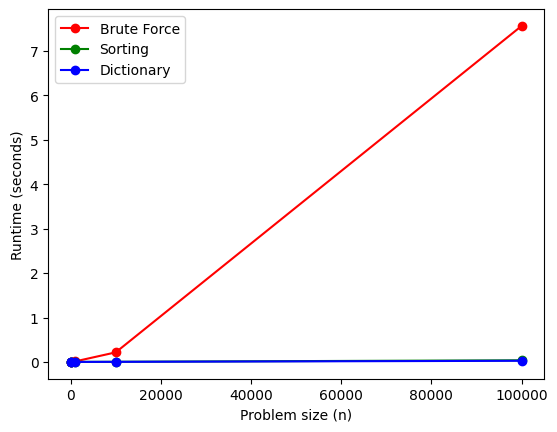

In [10]:
import matplotlib.pyplot as plt
ns = [10, 100, 1000, 10000, 100000]
ts_brute = [rearrangement_timing_test(are_rearrangements_brute, n) for n in ns]
ts_sort = [rearrangement_timing_test(are_rearrangements_sort, n) for n in ns]
ts_dict = [rearrangement_timing_test(are_rearrangements_dict, n) for n in ns]
plt.plot(ns, ts_brute, 'ro-')
plt.plot(ns, ts_sort, 'go-')
plt.plot(ns, ts_dict, 'bo-')
plt.xlabel('Problem size (n)')
plt.ylabel('Runtime (seconds)');
plt.legend(['Brute Force', 'Sorting', 'Dictionary'])
#plt.yscale('log')

## Anagram Pairs

An **anagram** is a word or phrase formed by rearranging the letters of another word or phrase, using all the original letters exactly once.

For example:

* *listen* and *silent* are anagrams.
* *evil* and *vile* are anagrams.

Two strings are anagrams if they contain the same letters with the same frequencies, possibly in a different order.


In [11]:
def is_anagram(a, b):
  return sorted(a) == sorted(b)

# This is not the optimal (linear-time) solution because sorting dominates
# the runtime. However, for typical word inputs where the length of the
# string is bounded by a small constant, this approach is still very
# efficient in practice and is often the simplest correct solution.

Given a word list, find all pairs in the list that are anagrams of each other.

In [12]:
def all_anagram_pairs(word_list):
  pairs = []
  for i in range(len(word_list)):
    for j in range(i+1, len(word_list)):
      if is_anagram(word_list[i], word_list[j]):
        pairs.append((word_list[i], word_list[j]))
  return pairs


In [13]:
short_word_list = ['proudest', 'stop', 'pots', 'tops', 'sprouted']
print(all_anagram_pairs(short_word_list))

[('proudest', 'sprouted'), ('stop', 'pots'), ('stop', 'tops'), ('pots', 'tops')]


### Testing on A Big List Of Words

Run ths to download a list of MANY English words and store them in a variable `word_list`.



In [14]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download('https://github.com/AllenDowney/DSIRP/raw/main/american-english')


def read_words(filename):
    """Read lines from a file and split them into words."""
    res = set()
    for line in open(filename):
        for word in line.split():
            res.add(word.strip().lower())
    return list(res)

word_list = read_words('american-english')
len(word_list)

Downloaded american-english


100781

Hmmm.......

In [15]:
print(all_anagram_pairs(word_list))

KeyboardInterrupt: 

In [16]:
def all_anagrams_dict(word_list):
  anagrams = {}
  for word in word_list:
    key = ''.join(sorted(word)) #if w ordis "stop", then key is "opst"
    if key in anagrams:
      anagrams[key].append(word)
    else:
      anagrams[key]= [word]
  return anagrams

In [20]:
anagram_map = all_anagrams_dict(word_list)
print(anagram_map)


{'afmrs': ['farms'], 'aefginnn': ['finnegan'], 'beeefir': ['beefier', 'freebie'], 'bdnoor': ['bordon'], "'hiilppss": ["philips's"], 'egginosss': ['sogginess'], 'adeosttuy': ['outstayed'], 'ahmnu': ['nahum', 'human'], 'accghin': ['caching'], 'aacinr': ['carina', 'crania'], 'abderrsu': ['absurder'], 'aceegllou': ['colleague'], 'aahps': ['pasha'], 'elmott': ['mottle'], "'behorst": ["bother's"], 'abehnrsss': ['brashness'], 'adeppr': ['rapped', 'dapper'], 'ceeehiknss': ['cheekiness'], 'ddeeeilnnnpty': ['independently'], 'apst': ['past', 'spat', 'taps', 'pats'], "'aprsty": ["party's"], "'enrssswy": ["wryness's"], 'cefgiinrty': ['certifying', 'rectifying'], 'pt': ['pt'], 'abcfilo': ['bifocal'], 'deimnoosx': ['monoxides'], "'aehmrst": ["mather's"], "'deinsw": ["wendi's", "edwin's"], "'aahinsst": ["ashanti's", "tanisha's"], 'abbegilnor': ['belaboring'], "'pssy": ["spy's"], 'ddfily': ['fiddly'], "'eimmrssw": ["swimmer's"], 'aaiksstw': ['swastika'], 'abeel': ['albee'], 'eefgiinrst': ['gentrifies'

## Exercises


**Exercise 1:**
Make a dictionary like `anagram_map` that contains only keys that map to a list with more than one element. You can use a `for` loop to make a new dictionary, or a [dictionary comprehension](https://www.freecodecamp.org/news/dictionary-comprehension-in-python-explained-with-examples/).

In [21]:
real_anagrams = {k:anagram_map[k] for k in anagram_map if len(anagram_map[k]) > 1}
print(real_anagrams)

{'beeefir': ['beefier', 'freebie'], 'ahmnu': ['nahum', 'human'], 'aacinr': ['carina', 'crania'], 'adeppr': ['rapped', 'dapper'], 'apst': ['past', 'spat', 'taps', 'pats'], 'cefgiinrty': ['certifying', 'rectifying'], "'deinsw": ["wendi's", "edwin's"], "'aahinsst": ["ashanti's", "tanisha's"], "'aiinnorstu": ["urination's", "ruination's"], 'mu': ['mu', 'um'], 'aeegnr': ['enrage', 'genera'], 'doors': ['odors', 'roods', 'doors'], 'eiknrstt': ['trinkets', 'knitters'], "'ipst": ["pit's", "tip's"], 'aehrs': ['shear', 'hears', 'share', 'rheas', 'hares'], 'begilnss': ['glibness', 'blessing'], 'elmrty': ['myrtle', 'termly'], 'aceprss': ['parsecs', 'scrapes'], 'abeirs': ['braise', 'serbia', 'rabies'], 'acddeenst': ['decadents', 'descanted'], 'hnstu': ['hunts', 'shunt'], 'adinsv': ['viands', 'divans'], "'eeilss": ["elise's", "elsie's"], 'acdir': ['acrid', 'dirac'], 'girst': ['grits', 'girts', 'grist'], "'aelsu": ["laue's", "eula's"], "'iorst": ["tiro's", "trio's", "riot's"], 'eiimnoprss': ['impressi


**Exercise 2:**
Find the longest word with at least one anagram. Suggestion: use the key argument of sort or sorted (see here).

In [22]:
longest_key = max(real_anagrams.keys(), key=len)
print(real_anagrams[longest_key])

["permissiveness's", "impressiveness's"]


**Exercise 3**:
Find the largest list of words that are anagrams of each other.

In [23]:
longest_val = max(real_anagrams.values(), key=len)
print(longest_val)

['stael', 'least', 'steal', 'teals', 'stale', 'tesla', 'tales', 'slate']
